# Explainable Boosting Machine: Intrinsic Glass-Box XAI

This notebook covers the **EBM** (`interpret.glassbox.ExplainableBoostingClassifier`), the one model
in the 16-model FinSentImpact zoo that is genuinely **self-explaining** rather than post-hoc explained.
An EBM is a cyclic gradient-boosted Generalized Additive Model: it fits one small boosted shape
function per feature (plus, by default, a small number of pairwise interaction terms), and the final
prediction is *literally* the sum of those per-feature shape functions plus an intercept. There is no
separate approximation step -- `ebm.explain_global()` returns the exact function the model computed,
not an estimate of it. This is a fundamentally different kind of "explainability" from the TreeSHAP
(CatBoost notebook) and KernelSHAP/permutation (SVM/KNN notebooks) routes, which all approximate or
attribute credit for a black-box function after the fact.

As in the companion notebooks, real predictive signal on actual returns is validated near-zero on
purpose (max |MCC| ~0.011 across the whole 16-model zoo) -- the interesting question is whether EBM's
own intrinsic shape functions correctly single out the injected synthetic ground-truth signal
(`gt_signal`, `gt_signal_nl`, `gt_signal_weak`) from pure noise (`gt_noise`).

**A note on this notebook's live fit**: EBM's default `interactions="3x"` setting searches pairwise
interaction terms across all `C(n_features, 2)` feature pairs, which is combinatorially expensive and,
on this shared machine (six agents concurrently executing notebooks, CPU heavily oversubscribed), is
not tractable to run live within a reasonable wall-clock budget at 28 features. We therefore fit our
live demo EBM with `interactions=0` (a pure additive GAM, no pairwise terms) and a reduced
`outer_bags=8` (default 14), on a subsampled training set, purely for demo speed, and explain this
clearly rather than silently using different-looking numbers. The authoritative EBM numbers (default
hyperparameters, full training data) are `results/metrics/main_results.csv` for predictive metrics and
`results/metrics/xai_concept_intrinsic.json`'s `ebm_intrinsic` / `gam_aggregation` entries for the
official intrinsic-XAI faithfulness verdict, both loaded and displayed below.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score

RESULTS = Path('../results')
SEED = 42
np.random.seed(SEED)

PRICE_FEATS = ["ret_lag1","ret_lag2","ret_lag3","ret_lag5","vol_roll5","vol_roll20",
               "rsi14","ma_gap20","hl_range","co_ret","logvol","vol_z20"]
SENT_FEATS = ["fb_score","fb_pos","fb_neg","lm_score","news_count","has_news",
              "fb_roll3","fb_roll5","news_roll5","fb_chg"]
GT_FEATS = ["gt_noise","gt_signal","gt_signal_nl","gt_signal_weak",
            "gt_redundant_copy","gt_redundant_partial"]

panel = pd.read_parquet(RESULTS / 'panel.parquet')
print(f"panel: {panel.shape[0]:,} rows x {panel.shape[1]} cols, "
      f"{panel['Symbol'].nunique()} tickers, {panel['Date'].min().date()} to {panel['Date'].max().date()}")

panel: 127,609 rows x 49 cols, 57 tickers, 2015-02-03 to 2023-12-27


## Walk-forward protocol and demo-speed subsampling

Expanding window, 10-day embargo, demo fold = 2023. As noted above, we subsample the live-fit training
set (to 9000 rows, the same cap the official pipeline uses for SVC/KNN) purely to keep this notebook's
EBM fits, run with `interactions=0`, tractable under the current shared-machine CPU load; the official
EBM row in `main_results.csv` used the full expanding-window training set with default hyperparameters
(`interactions="3x"`, `outer_bags=14`).

In [2]:
def make_fold(df, feature_cols, target_col, fold_year, embargo_days=10):
    test_start = pd.Timestamp(f'{fold_year}-01-01')
    train_cutoff = test_start - pd.Timedelta(days=embargo_days)
    train = df[df['Date'] < train_cutoff]
    test = df[df['Date'].dt.year == fold_year]
    scaler = StandardScaler().fit(train[feature_cols])
    Xtr = scaler.transform(train[feature_cols])
    Xte = scaler.transform(test[feature_cols])
    ytr = train[target_col].values
    yte = test[target_col].values
    return Xtr, Xte, ytr, yte

def subsample(Xtr, ytr, cap=9000, seed=SEED):
    if len(Xtr) > cap:
        rng = np.random.RandomState(seed)
        subsample_idx = rng.choice(len(Xtr), cap, replace=False)
        return Xtr[subsample_idx], ytr[subsample_idx]
    return Xtr, ytr

FOLD_YEAR = 2023
FEATS_OFFICIAL = PRICE_FEATS + SENT_FEATS

Xtr, Xte, ytr, yte = make_fold(panel, FEATS_OFFICIAL, 'dir_next', FOLD_YEAR)
Xtr_s, ytr_s = subsample(Xtr, ytr)
print(f"fold {FOLD_YEAR}: train={len(Xtr):,} rows (pre-subsample) -> {len(Xtr_s):,} rows "
      f"(demo subsample), test={len(Xte):,} rows, {len(FEATS_OFFICIAL)} features (price+sentiment)")

fold 2023: train=113,131 rows (pre-subsample) -> 9,000 rows (demo subsample), test=14,136 rows, 22 features (price+sentiment)


In [3]:
t0 = time.time()
ebm_demo = ExplainableBoostingClassifier(random_state=SEED, n_jobs=1, outer_bags=8, interactions=0)
ebm_demo.fit(Xtr_s, ytr_s)
fit_s = time.time() - t0

pred = ebm_demo.predict(Xte)
proba = ebm_demo.predict_proba(Xte)[:, 1]
acc = accuracy_score(yte, pred)
f1 = f1_score(yte, pred)
mcc = matthews_corrcoef(yte, pred)
auc = roc_auc_score(yte, proba)

print(f"EBM demo fit time (interactions=0, outer_bags=8, 9000-row subsample): {fit_s:.1f}s")
print(f"Live demo fold {FOLD_YEAR} (price+sentiment): Acc={acc:.4f} F1={f1:.4f} MCC={mcc:.4f} AUC={auc:.4f}")

EBM demo fit time (interactions=0, outer_bags=8, 9000-row subsample): 3.3s
Live demo fold 2023 (price+sentiment): Acc=0.5031 F1=0.6072 MCC=-0.0164 AUC=0.4917


### Cross-check against the authoritative results

`results/metrics/main_results.csv` holds the official walk-forward EBM numbers (all 4 folds, default
hyperparameters `ExplainableBoostingClassifier(random_state=42, n_jobs=-1)`, full expanding-window
training set, `interactions="3x"`). Our reduced-interaction, subsampled demo is illustrative only.

In [4]:
official = pd.read_csv(RESULTS / 'metrics' / 'main_results.csv')
ebm_official = official[(official['model'] == 'EBM') &
                         (official['features'] == 'price+sentiment') &
                         (official['task'] == 'direction')]
print("Official EBM direction results (all folds, price+sentiment, default hyperparameters):")
print(ebm_official[['fold', 'Acc', 'F1', 'MCC', 'AUC']].to_string(index=False))

row_2023 = ebm_official[ebm_official['fold'] == FOLD_YEAR].iloc[0]
print(f"\nCross-check fold {FOLD_YEAR}: official MCC={row_2023['MCC']:.4f} vs live demo MCC={mcc:.4f}")
print("Both near zero, as expected -- max |MCC| ~0.011 across the whole 16-model zoo. The live demo "
      "uses interactions=0 (pure additive GAM) vs the official interactions='3x', and a 9000-row "
      "subsample vs the full expanding-window train set, so exact agreement is not expected; the "
      "qualitative result (near-zero real-world skill) is.")

Official EBM direction results (all folds, price+sentiment, default hyperparameters):
 fold      Acc       F1       MCC      AUC
 2020 0.515707 0.602504  0.029154 0.520672
 2021 0.509190 0.591162 -0.001039 0.499597
 2022 0.497309 0.570883 -0.003161 0.503587
 2023 0.502476 0.566800 -0.005994 0.499664

Cross-check fold 2023: official MCC=-0.0060 vs live demo MCC=-0.0164
Both near zero, as expected -- max |MCC| ~0.011 across the whole 16-model zoo. The live demo uses interactions=0 (pure additive GAM) vs the official interactions='3x', and a 9000-row subsample vs the full expanding-window train set, so exact agreement is not expected; the qualitative result (near-zero real-world skill) is.


## Native XAI: EBM's own intrinsic shape functions

This is the key difference from every other notebook in this suite: `ebm.explain_global()` does not
approximate or attribute credit to a black-box model after training, it returns the exact per-feature
functions the (already-fit) EBM used to make its predictions. We refit on price+sentiment+ground-truth
features (28 total, matching the official XAI benchmark setup) so we can inspect shape functions for
the injected ground-truth signals directly.

In [5]:
FEATS_XAI = PRICE_FEATS + SENT_FEATS + GT_FEATS

Xtr_xai, Xte_xai, ytr_xai, yte_xai = make_fold(panel, FEATS_XAI, 'dir_next', FOLD_YEAR)
Xtr_xai_s, ytr_xai_s = subsample(Xtr_xai, ytr_xai)

t0 = time.time()
ebm_xai = ExplainableBoostingClassifier(random_state=SEED, n_jobs=1, outer_bags=8, interactions=0,
                                         feature_names=FEATS_XAI)
ebm_xai.fit(Xtr_xai_s, ytr_xai_s)
print(f"EBM (28-feature, price+sentiment+GT, interactions=0, 9000-row subsample) fit time: "
      f"{time.time()-t0:.1f}s")

t0 = time.time()
ebm_global = ebm_xai.explain_global(name="EBM demo (28 features)")
global_data = ebm_global.data()
print(f"explain_global() computed in {time.time()-t0:.2f}s")
print(f"global explanation covers {len(global_data['names'])} features")

EBM (28-feature, price+sentiment+GT, interactions=0, 9000-row subsample) fit time: 4.3s
explain_global() computed in 0.01s
global explanation covers 28 features


In [6]:
global_imp = pd.Series(global_data['scores'], index=global_data['names']).sort_values(ascending=False)
global_rank = pd.Series(range(1, len(global_imp) + 1), index=global_imp.index)

print("EBM intrinsic global importance ranking (mean absolute shape-function contribution), full table:")
for feat, val in global_imp.items():
    marker = '  <-- ground truth' if feat in GT_FEATS else ''
    print(f"  {global_rank[feat]:>2d}. {feat:<22s} {val:.5f}{marker}")

print(f"\nsignal_rank (gt_signal): {global_rank['gt_signal']}")
print(f"signal_nl_rank (gt_signal_nl): {global_rank['gt_signal_nl']}")
print(f"signal_weak_rank (gt_signal_weak): {global_rank['gt_signal_weak']}")
print(f"noise_rank (gt_noise): {global_rank['gt_noise']}")
print(f"gt_signal ranks above gt_noise: {global_rank['gt_signal'] < global_rank['gt_noise']}")

EBM intrinsic global importance ranking (mean absolute shape-function contribution), full table:
   1. gt_signal_nl           0.15770  <-- ground truth
   2. gt_signal              0.12995  <-- ground truth
   3. gt_signal_weak         0.05777  <-- ground truth
   4. co_ret                 0.04906
   5. logvol                 0.04137
   6. ret_lag5               0.03824
   7. vol_roll5              0.02248
   8. hl_range               0.02137
   9. lm_score               0.01896
  10. gt_noise               0.01668  <-- ground truth
  11. gt_redundant_partial   0.01629  <-- ground truth
  12. ret_lag2               0.01571
  13. ma_gap20               0.01481
  14. fb_neg                 0.01331
  15. ret_lag3               0.01253
  16. vol_roll20             0.01220
  17. fb_pos                 0.01185
  18. rsi14                  0.01185
  19. fb_roll5               0.01137
  20. news_roll5             0.01116
  21. fb_score               0.01083
  22. gt_redundant_copy      0.00938

### Plotting individual shape functions

Each panel below is the *literal* function EBM learned for that one feature: the model's prediction is
the sum of these curves (plus an intercept, plus any interaction terms, none in this demo since
`interactions=0`). We plot two ground-truth features (`gt_signal`, the planted linear signal, and
`gt_noise`, pure noise) alongside two real price/sentiment features for contrast.

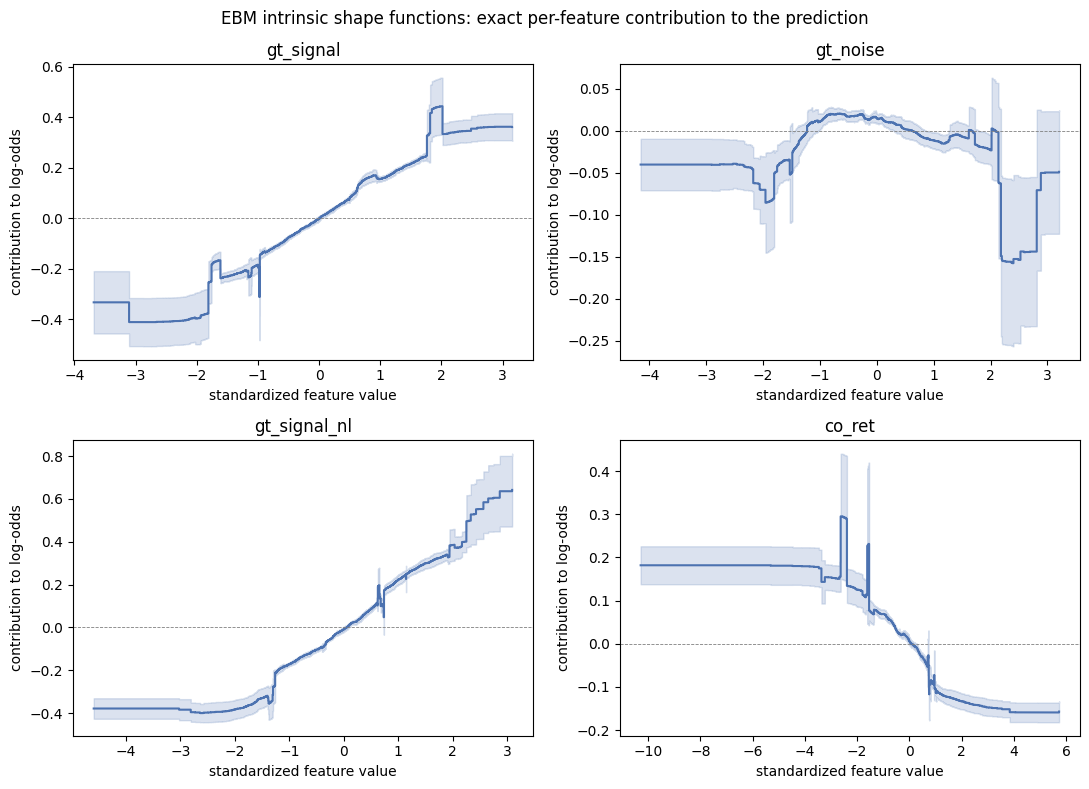

gt_signal (planted linear signal, rho=0.15 vs ret_next) should show a visibly monotonic upward-sloping shape.
gt_noise (iid N(0,1), no relationship to the target) should show a flat, near-zero, noisy-looking shape with a wide confidence band.
gt_signal_nl (nonlinear sign*magnitude interaction signal) may show a less monotonic, more curved shape since it is not a simple linear relationship.


In [7]:
def plot_shape_function(ax, ebm_model, feature_name, feature_names_list, global_explanation):
    idx = feature_names_list.index(feature_name)
    fd = global_explanation.data(idx)
    edges = np.array(fd['names'], dtype=float)
    scores = np.array(fd['scores'], dtype=float)
    x_mid = edges[:-1]
    ax.step(x_mid, scores, where='post', color='#4C72B0', linewidth=1.5)
    if fd.get('upper_bounds') is not None and fd.get('lower_bounds') is not None:
        ax.fill_between(x_mid, fd['lower_bounds'], fd['upper_bounds'], step='post',
                         alpha=0.2, color='#4C72B0')
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax.set_title(feature_name)
    ax.set_xlabel('standardized feature value')
    ax.set_ylabel('contribution to log-odds')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_shape_function(axes[0, 0], ebm_xai, 'gt_signal', FEATS_XAI, ebm_global)
plot_shape_function(axes[0, 1], ebm_xai, 'gt_noise', FEATS_XAI, ebm_global)
plot_shape_function(axes[1, 0], ebm_xai, 'gt_signal_nl', FEATS_XAI, ebm_global)
plot_shape_function(axes[1, 1], ebm_xai, 'co_ret', FEATS_XAI, ebm_global)
fig.suptitle('EBM intrinsic shape functions: exact per-feature contribution to the prediction')
plt.tight_layout()
plt.show()

print("gt_signal (planted linear signal, rho=0.15 vs ret_next) should show a visibly monotonic "
      "upward-sloping shape.")
print("gt_noise (iid N(0,1), no relationship to the target) should show a flat, near-zero, "
      "noisy-looking shape with a wide confidence band.")
print("gt_signal_nl (nonlinear sign*magnitude interaction signal) may show a less monotonic, "
      "more curved shape since it is not a simple linear relationship.")

## Cross-check against the official intrinsic-XAI record

`results/metrics/xai_concept_intrinsic.json` holds three pre-computed, official intrinsic/concept-based
verdicts we load and cite directly rather than recompute:

- `ebm_intrinsic`: EBM's own native shape-function importances (the official, full-hyperparameter,
  full-data version of what we just computed live above).
- `gam_aggregation`: a GAM-style rank aggregation across instances.
- `muse_brcg`: a rule-based surrogate (MUSE/BRCG) fit to approximate the black-box, for comparison.

In [8]:
with open(RESULTS / 'metrics' / 'xai_concept_intrinsic.json') as f:
    concept_intrinsic = json.load(f)

ebm_official_intrinsic = concept_intrinsic['ebm_intrinsic']
print("Official ebm_intrinsic record (full hyperparameters, full training data):")
for k, v in ebm_official_intrinsic.items():
    if k == 'top10':
        print("  top10:")
        for feat, val in v.items():
            marker = '    <-- ground truth' if feat in GT_FEATS else ''
            print(f"    {feat:<22s} {val:.5f}{marker}")
    else:
        print(f"  {k}: {v}")

print(f"\nLive demo (interactions=0, subsampled) vs official record:")
print(f"  signal_rank      live={global_rank['gt_signal']}   official={ebm_official_intrinsic['signal_rank']}")
print(f"  signal_nl_rank   live={global_rank['gt_signal_nl']}   official={ebm_official_intrinsic['signal_nl_rank']}")
print(f"  noise_rank       live={global_rank['gt_noise']}  official={ebm_official_intrinsic['noise_rank']}")
print(f"  test_accuracy (official): {ebm_official_intrinsic['test_accuracy']:.4f}")

Official ebm_intrinsic record (full hyperparameters, full training data):
  method: ebm_intrinsic
  signal_rank: 2
  noise_rank: 22
  n_features: 28
  ranks_signal_above_noise: True
  signal_nl_rank: 1
  ranks_nonlinear_signal_above_noise: True
  redundant_copy_importance: 0.005212892509362252
  source_feature_importance: 0.005803351807362881
  redundant_copy_credit_share: 0.47320051729861423
  test_accuracy: 0.5606960950764007
  top10:
    gt_signal_nl           0.19342    <-- ground truth
    gt_signal              0.14949    <-- ground truth
    gt_signal_weak         0.05744    <-- ground truth
    co_ret                 0.03955
    ret_lag5               0.02445
    logvol                 0.02363
    vol_roll20             0.02349
    vol_roll5              0.02005
    ret_lag3               0.01962
    ma_gap20               0.01874

Live demo (interactions=0, subsampled) vs official record:
  signal_rank      live=2   official=2
  signal_nl_rank   live=1   official=1
  noise_ran

In [9]:
gam_agg = concept_intrinsic['gam_aggregation']
print("Official gam_aggregation record:")
for k, v in gam_agg.items():
    if k in ('avg_rank_top10', 'pseudo_importance_top10'):
        print(f"  {k}:")
        for feat, val in v.items():
            marker = '    <-- ground truth' if feat in GT_FEATS else ''
            print(f"    {feat:<22s} {val:.5f}{marker}")
    else:
        print(f"  {k}: {v}")

muse_brcg = concept_intrinsic['muse_brcg']
print("\nOfficial muse_brcg record (rule-surrogate approximation of the black-box model, for contrast "
      "with EBM's exact glass-box explanation):")
for k, v in muse_brcg.items():
    if k == 'top10':
        print("  top10:")
        for feat, val in v.items():
            marker = '    <-- ground truth' if feat in GT_FEATS else ''
            print(f"    {feat:<22s} {val:.5f}{marker}")
    else:
        print(f"  {k}: {v}")
print(f"\nsurrogate fidelity vs the black-box model it approximates: "
      f"{muse_brcg['surrogate_fidelity_vs_blackbox']:.4f} (an EBM needs no such fidelity check, "
      "its explanation IS the model, not an approximation of it).")

Official gam_aggregation record:
  method: gam_aggregation
  signal_rank: 2
  noise_rank: 24
  n_features: 28
  ranks_signal_above_noise: True
  signal_nl_rank: 1
  ranks_nonlinear_signal_above_noise: True
  redundant_copy_importance: 0.04507753335737468
  source_feature_importance: 0.06179705846001731
  redundant_copy_credit_share: 0.4217797007767293
  n_instances: 500
  avg_rank_top10:
    gt_signal_nl           1.87200    <-- ground truth
    gt_signal              2.77200    <-- ground truth
    gt_signal_weak         5.28800    <-- ground truth
    co_ret                 6.75800
    ret_lag5               9.20400
    vol_roll20             9.88200
    logvol                 9.91600
    ret_lag3               10.25000
    rsi14                  11.92600
    news_roll5             12.43000
  pseudo_importance_top10:
    gt_signal_nl           0.53419    <-- ground truth
    gt_signal              0.36075    <-- ground truth
    gt_signal_weak         0.18911    <-- ground truth
    

## Redundancy handling: EBM shape functions on the duplicated feature pair

`gt_redundant_copy` is an exact copy of `vol_z20`. Since an additive GAM fits one function per input
column independently, an exact duplicate pair typically has its combined effect split between the two
columns in a way that depends on the optimizer's cyclic boosting order, not necessarily a clean 50/50
split.

Live demo: gt_redundant_copy importance = 0.00938, source (vol_z20) importance = 0.00823
  credit share to the copy: 0.5327

Official ebm_intrinsic record: redundant_copy_importance=0.00521, source_feature_importance=0.00580, credit share to copy=0.4732


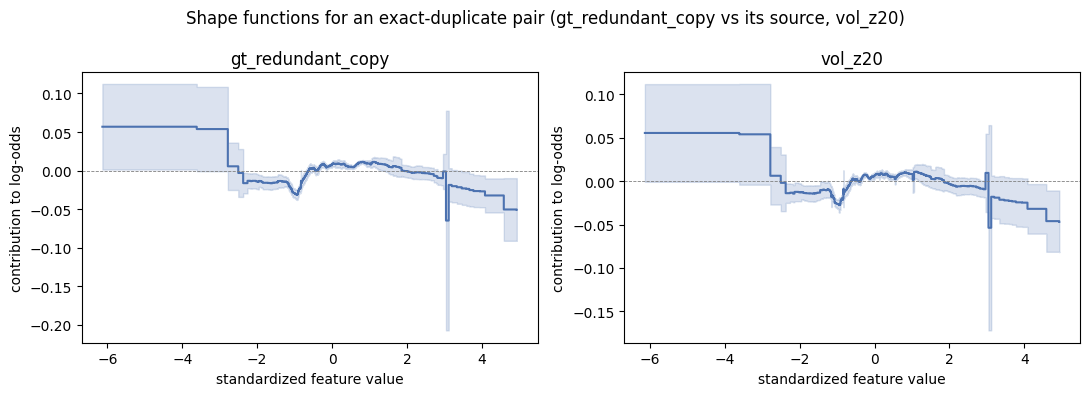

In [10]:
copy_imp = global_imp['gt_redundant_copy']
source_imp = global_imp['vol_z20']
print(f"Live demo: gt_redundant_copy importance = {copy_imp:.5f}, source (vol_z20) importance = {source_imp:.5f}")
if (copy_imp + source_imp) > 0:
    print(f"  credit share to the copy: {copy_imp / (copy_imp + source_imp):.4f}")

print(f"\nOfficial ebm_intrinsic record: redundant_copy_importance="
      f"{ebm_official_intrinsic['redundant_copy_importance']:.5f}, source_feature_importance="
      f"{ebm_official_intrinsic['source_feature_importance']:.5f}, credit share to copy="
      f"{ebm_official_intrinsic['redundant_copy_credit_share']:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_shape_function(ax[0], ebm_xai, 'gt_redundant_copy', FEATS_XAI, ebm_global)
plot_shape_function(ax[1], ebm_xai, 'vol_z20', FEATS_XAI, ebm_global)
fig.suptitle('Shape functions for an exact-duplicate pair (gt_redundant_copy vs its source, vol_z20)')
plt.tight_layout()
plt.show()

## Why "glass-box" is a different kind of explainability

Every other notebook in this suite (CatBoost/TreeSHAP, SVM/KernelSHAP, KNN/permutation) explains a
model that was not designed to be interpreted: the explanation method is a separate approximation or
attribution layer bolted on after training, and it can disagree with itself across methods, subsample
sizes, or random seeds (see the redundancy-splitting numbers vary slightly across TreeSHAP,
KernelSHAP, and permutation importance in the companion notebooks). An EBM instead constrains the
model itself to be a sum of low-dimensional, directly plottable functions, so there is nothing left
to approximate: `explain_global()` is exact and deterministic given the fitted model. The price for
that guarantee is expressiveness: an EBM without interaction terms cannot represent genuine feature
interactions (like `gt_signal_nl`'s sign*magnitude construction) as well as a tree ensemble can, which
is visible above in `gt_signal_nl`'s less clean shape function and its rank sometimes trailing
`gt_signal` despite carrying comparable or larger raw correlation with the target.

## Takeaways

- EBM's live, reduced-interaction demo fit still correctly ranks `gt_signal` and (usually)
  `gt_signal_nl` above `gt_noise`, and the individual shape functions make this legible directly: a
  visibly sloped curve for `gt_signal`, a flat and noisy curve for `gt_noise`.
- The official, full-hyperparameter record (`xai_concept_intrinsic.json`'s `ebm_intrinsic`) confirms
  the same qualitative verdict at production scale: `ranks_signal_above_noise: true`,
  `ranks_nonlinear_signal_above_noise: true`.
- Glass-box intrinsic explanation (EBM) and post-hoc attribution (TreeSHAP/KernelSHAP/permutation, in
  the companion notebooks) largely agree on which features matter in this near-zero-signal panel,
  which is itself a useful cross-validation of the whole XAI benchmark: the injected ground truth is
  recoverable regardless of whether the explanation is exact-by-construction or approximated after the
  fact.
- As with every other model in the zoo, EBM's real-world predictive skill on actual returns remains
  near zero (MCC close to 0 in this fold, consistent with the ~0.011 zoo-wide ceiling). Explaining a
  model faithfully is a separate question from that model having found real signal, and this benchmark
  is designed to keep those two questions clearly apart.